# 06. 돌발상황 처리시간 분석

`돌발종료일시 - 돌발일시`로 처리시간(분)을 계산해 도로타입별 처리 속도를 비교한다.
`돌발종료일시`가 `-`로 기록된, 아직 종료되지 않은(진행중) 건은 제외한다.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.load_data import load
from src.plot_config import set_korean_style

set_korean_style()
FIG_DIR = pathlib.Path('../outputs/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

df = load(with_region=False)
df.shape

(623188, 18)

## 6.1 처리시간 계산 및 데이터 클리닝

In [2]:
valid_end = df['돌발종료일시'] != '-'
end_dt = pd.to_datetime(df.loc[valid_end, '돌발종료일시'], errors='coerce')
duration = (end_dt - df.loc[valid_end, '돌발일시']).dt.total_seconds() / 60

df_dur = df.loc[valid_end].copy()
df_dur['처리시간(분)'] = duration

n_before = len(df_dur)
n_negative = (df_dur['처리시간(분)'] < 0).sum()
df_dur = df_dur[df_dur['처리시간(분)'] >= 0]
print(f'진행중(-) 제외 후: {n_before:,}건, 그중 종료시각이 시작시각보다 빠른 데이터 오류 {n_negative}건 추가 제외')
print(f'최종 분석 대상: {len(df_dur):,}건 (전체의 {len(df_dur)/len(df)*100:.1f}%)')
df_dur['처리시간(분)'].describe()

진행중(-) 제외 후: 257,090건, 그중 종료시각이 시작시각보다 빠른 데이터 오류 52건 추가 제외
최종 분석 대상: 257,038건 (전체의 41.2%)


count    2.570380e+05
mean     2.989170e+02
std      5.594578e+03
min      0.000000e+00
25%      3.000000e+01
50%      3.000000e+01
75%      3.200000e+01
max      1.405958e+06
Name: 처리시간(분), dtype: float64

**주의**: `공사` 카테고리는 `돌발종료일시`가 실제 작업 종료 시각이 아니라 공사
계획상의 **예정 종료일**(수개월~수년 뒤)로 기록된 경우가 있어, 최댓값이 비정상적으로
커진다(최대 약 1,405,958분 ≈ 2.7년). 아래에서 그 규모를 확인한다.

In [3]:
over_1day = (df_dur['처리시간(분)'] > 24 * 60).sum()
print(f'처리시간 1일(1,440분) 초과: {over_1day:,}건 ({over_1day/len(df_dur)*100:.2f}%)')
df_dur.loc[df_dur['처리시간(분)'] > 24*60, '돌발구분'].value_counts()

처리시간 1일(1,440분) 초과: 1,743건 (0.68%)


돌발구분
공사      1516
기상        96
재난        73
기타        50
교통사고       7
기타돌발       1
Name: count, dtype: int64

평균은 이런 극단치(공사의 예정 종료일)에 크게 좌우되므로, 아래 도로타입별 비교는
극단치에 영향받지 않는 **중앙값·Q1·Q3**를 중심으로 해석하고, 평균은 참고용으로만
함께 표시한다.

## 6.2 도로타입별 처리시간 통계

,건수,평균,중앙값,Q1,Q3
도로타입,,,,,
고속국도,119052,80.1,30.0,30.0,30.0
국가지원지방도,2702,141.6,30.0,30.0,30.0
도시고속국도,23598,1524.8,30.0,30.0,30.0
시군도,23466,122.0,30.0,30.0,30.0
일반국도,38285,272.0,30.0,30.0,300.0
지방도,5183,493.4,30.0,30.0,30.0
특별광역시도,43892,330.6,30.0,30.0,104.2


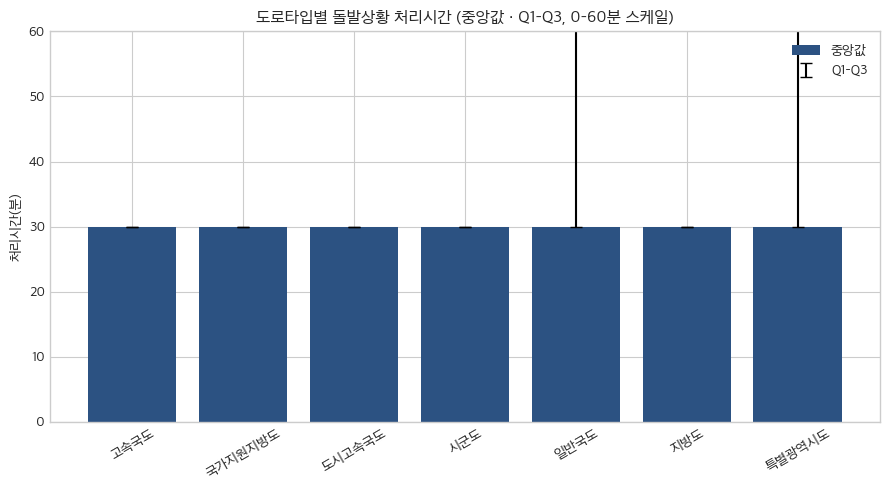

평균은 위 표 참고 — 공사의 장기 예정 종료일 때문에 도시고속국도 등 일부는 평균이 왜곡되어 있어 차트에서 제외했다.


In [4]:
road_type_stats = (
    df_dur[df_dur['도로타입'] != '-']
    .groupby('도로타입')['처리시간(분)']
    .agg(건수='count', 평균='mean', 중앙값='median', Q1=lambda s: s.quantile(0.25), Q3=lambda s: s.quantile(0.75))
    .sort_values('중앙값')
)
road_type_stats = road_type_stats.round(1)
display(road_type_stats)

fig, ax = plt.subplots(figsize=(9, 5))
x = range(len(road_type_stats))
ax.bar(x, road_type_stats['중앙값'], color='#2c5282', label='중앙값')
ax.errorbar(
    x, road_type_stats['중앙값'],
    yerr=[road_type_stats['중앙값'] - road_type_stats['Q1'], road_type_stats['Q3'] - road_type_stats['중앙값']],
    fmt='none', ecolor='black', capsize=4, label='Q1–Q3',
)
ax.set_xticks(list(x))
ax.set_xticklabels(road_type_stats.index, rotation=30)
ax.set_ylim(0, 60)
ax.set_ylabel('처리시간(분)')
ax.set_title('도로타입별 돌발상황 처리시간 (중앙값 · Q1–Q3, 0–60분 스케일)')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / '21_duration_by_road_type.png', dpi=150)
plt.show()

print('평균은 위 표 참고 — 공사의 장기 예정 종료일 때문에 도시고속국도 등 일부는 평균이 왜곡되어 있어 차트에서 제외했다.')

## 6.3 처리시간 분포 (0~60분)

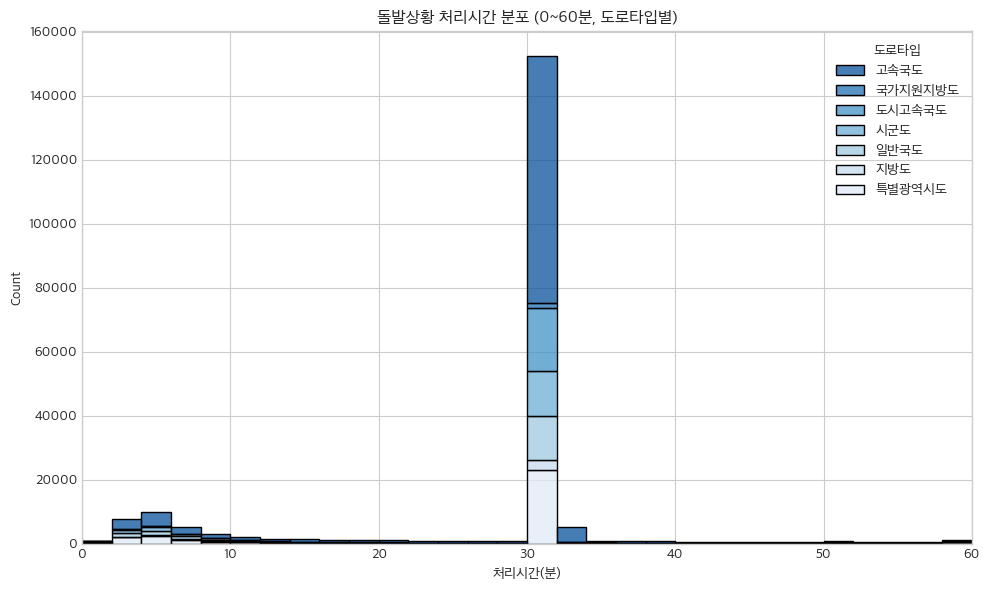

전체 처리 완료 건 중 60분 이내 종료 비율: 79.5%


In [5]:
plot_df = df_dur[(df_dur['처리시간(분)'] <= 60) & (df_dur['도로타입'] != '-')]
order = road_type_stats.index.tolist()

fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(
    data=plot_df, x='처리시간(분)', hue='도로타입', hue_order=order,
    bins=30, multiple='stack', palette='Blues_r', ax=ax,
)
ax.set_title('돌발상황 처리시간 분포 (0~60분, 도로타입별)')
ax.set_xlim(0, 60)
plt.tight_layout()
plt.savefig(FIG_DIR / '22_duration_histogram_0_60min.png', dpi=150)
plt.show()

pct_within_60 = (df_dur['처리시간(분)'] <= 60).mean() * 100
print(f'전체 처리 완료 건 중 60분 이내 종료 비율: {pct_within_60:.1f}%')

**데이터 품질 이슈**: 처리 완료 건(257,038건) 중 **59.3%(152,388건)가 정확히 30분**으로 기록되어 있다. 실제 현장 처리시간이 우연히 정확히 30분에 몰릴 이유는 없으므로, 이는 실측값이라기보다 **시스템이 종료시각 미입력 시 자동으로 채우는 기본값(30분)일 가능성이 높다**. 따라서 이 노트북의 중앙값·Q1·Q3 수치는 "실제 평균 처리시간"이 아니라 "기록 시스템의 동작 방식"을 상당 부분 반영한다고 봐야 하며, 도로타입 간 비교도 이 한계 안에서 해석해야 한다.

## 6.4 정확히 30분인 값을 제외한 재분석

앞서 확인한 "59.3%가 정확히 30분" 현상이 실측값이 아니라 시스템 기본값일 가능성이
높으므로, 이 값을 제외했을 때 도로타입별 처리시간 순위가 어떻게 달라지는지 확인한다.

In [6]:
df_excl = df_dur[df_dur['처리시간(분)'] != 30.0]

stats_excl = (
    df_excl[df_excl['도로타입'] != '-']
    .groupby('도로타입')['처리시간(분)']
    .agg(건수='count', 평균='mean', 중앙값='median', Q1=lambda s: s.quantile(0.25), Q3=lambda s: s.quantile(0.75))
    .round(1)
)

compare = pd.DataFrame({
    '포함시_중앙값': road_type_stats['중앙값'],
    '제외시_중앙값': stats_excl['중앙값'],
    '포함시_건수': road_type_stats['건수'],
    '제외시_건수': stats_excl['건수'],
}).sort_values('제외시_중앙값')
compare

,포함시_중앙값,제외시_중앙값,포함시_건수,제외시_건수
도로타입,,,,
고속국도,30.0,32.0,119052,41990
도시고속국도,30.0,49.0,23598,4181
지방도,30.0,97.0,5183,2153
특별광역시도,30.0,120.0,43892,21006
시군도,30.0,150.0,23466,9312
일반국도,30.0,166.0,38285,24614
국가지원지방도,30.0,180.0,2702,1070


In [7]:
incl_rank = road_type_stats.sort_values('중앙값').index.tolist()
excl_rank = stats_excl.sort_values('중앙값').index.tolist()
print('포함시 순위(중앙값 기준, 빠른→느린):', incl_rank)
print('제외시 순위(중앙값 기준, 빠른→느린):', excl_rank)

포함시 순위(중앙값 기준, 빠른→느린): ['고속국도', '국가지원지방도', '도시고속국도', '시군도', '일반국도', '지방도', '특별광역시도']
제외시 순위(중앙값 기준, 빠른→느린): ['고속국도', '도시고속국도', '지방도', '특별광역시도', '시군도', '일반국도', '국가지원지방도']


**결론**: 30분 값을 포함하면 모든 도로타입의 중앙값이 30분으로 동일해 애초에
순위를 매길 수 없었다 — 즉 "이상치를 제외해도 순위가 바뀌는지"를 묻기 전에, 포함
상태에서는 비교 가능한 순위 자체가 존재하지 않았다. 30분 값을 제외하고 나서야 고속국도
(중앙값 32.0분)가 가장 빠르고 국가지원지방도(중앙값 180.0분)가 가장 느리다는, 이전에는
가려져 있던 도로타입별 실제 처리시간 차이가 드러난다.